# **Digital Assignment 3**
## **Subject: Deep Learning Lab (PMDS603P)**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.optimizers.schedules import PolynomialDecay, ExponentialDecay
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import keras_tuner as kt
from keras.regularizers import l2
import tensorflow as tf

# **Question 1**

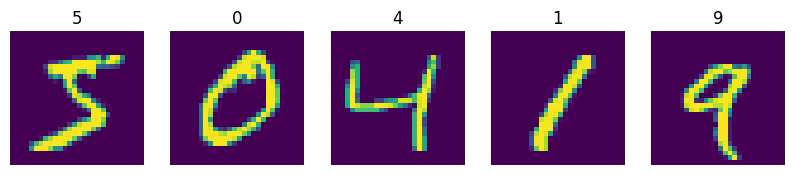

In [4]:
batch_size = 64
num_classes = 10
epochs = 500

(X_train, y_train), (X_test, y_test) = mnist.load_data()

fig, ax = plt.subplots(1, 5, figsize=(10, 2))


for i in range(5):
    ax[i].imshow(X_train[i])
    ax[i].axis('off')
    ax[i].set_title(y_train[i])

plt.show()

In [5]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255.0
X_test /= 255.0

## Model Building

In [6]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))
model.summary()

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

## SGD Optimizer & EarlyStopping

In [7]:
sgd = SGD(learning_rate=0.01)
estop = EarlyStopping(monitor='val_loss', min_delta=1e-4, mode='min', patience=5, verbose=1, restore_best_weights=True)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=[X_test, y_test], callbacks=[estop])

## Performance Report

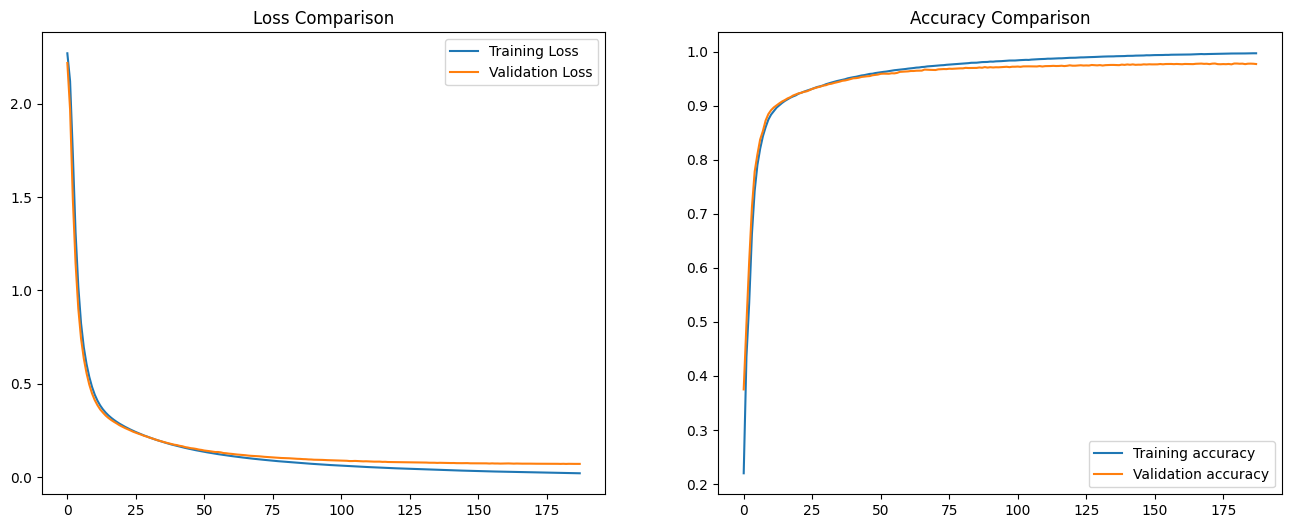

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(history.history['loss'], label='Training Loss')
axs[0].plot(history.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(history.history['accuracy'], label='Training accuracy')
axs[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

In [10]:
print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

Model Performance
loss=0.0708, acc=0.9776


In [20]:
predictions = model.predict(X_test)
for i in range(5):
    predicted_class = np.argmax(predictions[i]) 
    true_class = y_test[i]
    print(f"Image {i+1}: Predicted = {predicted_class}, True = {true_class}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step
Image 1: Predicted = 7, True = 7
Image 2: Predicted = 2, True = 2
Image 3: Predicted = 1, True = 1
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 4, True = 4


# **Question 2**

In [30]:
# linera Schedule
sgd_lin = SGD(learning_rate=0.01)

#Polynomial Decay
lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=0.01,
    decay_steps=5,
    end_learning_rate=0.001,
    power=2,
    cycle=False
)
sgd_poly = SGD(learning_rate=lr_schedule_poly)

#Exponential Decay
lr_schedule_expo = ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True
)
sgd_expo = SGD(learning_rate=lr_schedule_expo)

In [31]:
estop_for_schedulers = EarlyStopping(monitor='val_loss', min_delta=1e-3, mode='min', patience=5, verbose=1, restore_best_weights=True)

In [32]:
def build_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model


## Linear Scheduler

In [ ]:
model_lin = build_model()
model_lin.compile(optimizer=sgd_lin,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_lin = model_lin.fit(X_train, y_train, 
                              validation_data=(X_test, y_test),
                              epochs=20, verbose=2, callbacks=[estop_for_schedulers])

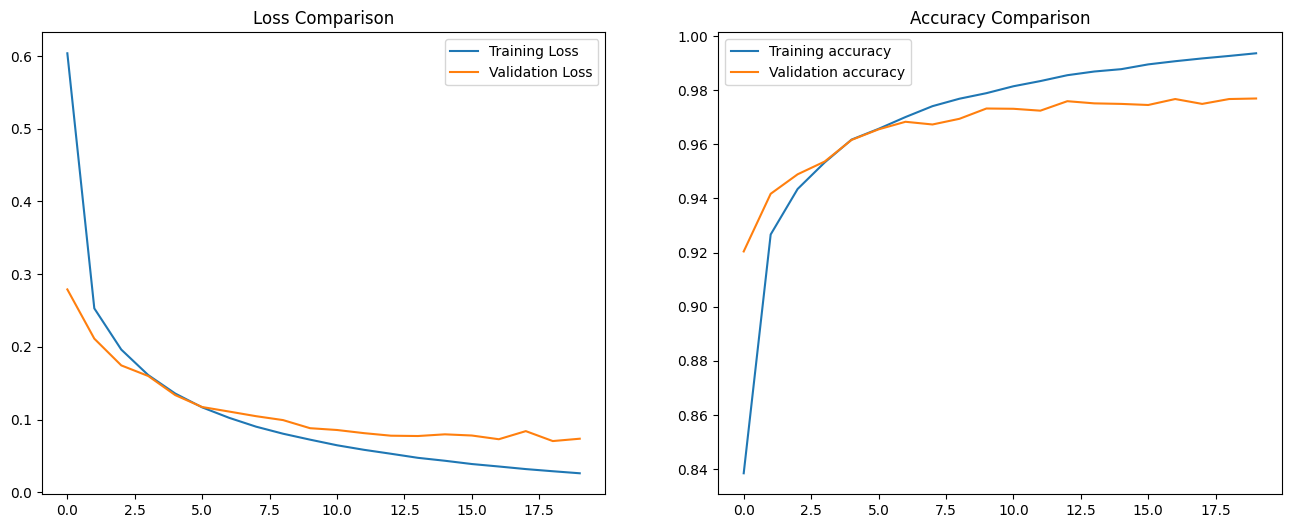

Model Performance
loss=0.0705, acc=0.9767
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step
Image 1: Predicted = 7, True = 7
Image 2: Predicted = 2, True = 2
Image 3: Predicted = 1, True = 1
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 4, True = 4


In [35]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(history_lin.history['loss'], label='Training Loss')
axs[0].plot(history_lin.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(history_lin.history['accuracy'], label='Training accuracy')
axs[1].plot(history_lin.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()


print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model_lin.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

predictions = model_lin.predict(X_test)
for i in range(5):
    predicted_class = np.argmax(predictions[i]) 
    print(f"Image {i+1}: Predicted = {predicted_class}, True = {y_test[i]}")

## Polynomial Decay Scheduler

In [ ]:
model_poly = build_model()
model_poly.compile(optimizer=sgd_poly,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_poly = model_poly.fit(X_train, y_train, 
                              validation_data=(X_test, y_test),
                              epochs=20, verbose=2, callbacks=[estop_for_schedulers])

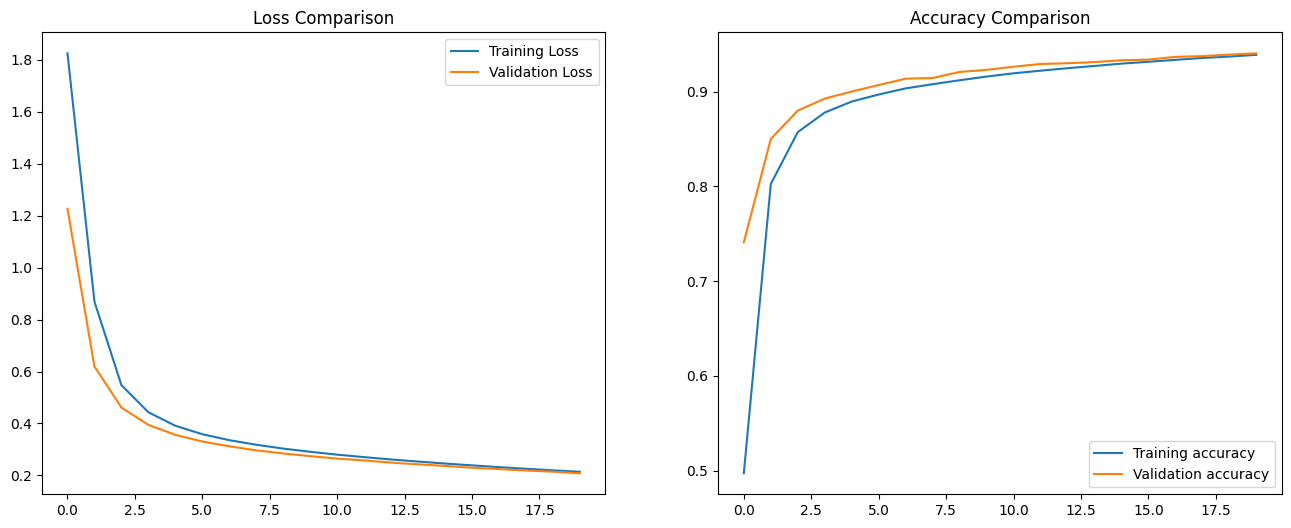

Model Performance
loss=0.2085, acc=0.9404
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step
Image 1: Predicted = 7, True = 7
Image 2: Predicted = 2, True = 2
Image 3: Predicted = 1, True = 1
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 4, True = 4


In [37]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(history_poly.history['loss'], label='Training Loss')
axs[0].plot(history_poly.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(history_poly.history['accuracy'], label='Training accuracy')
axs[1].plot(history_poly.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()


print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model_poly.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

predictions = model_poly.predict(X_test)
for i in range(5):
    predicted_class = np.argmax(predictions[i]) 
    print(f"Image {i+1}: Predicted = {predicted_class}, True = {y_test[i]}")

## Exponential Decay Scheduler

In [ ]:
model_expo = build_model()
model_expo.compile(optimizer=sgd_expo,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_expo = model_expo.fit(X_train, y_train, 
                              validation_data=(X_test, y_test),
                              epochs=20, verbose=2, callbacks=[estop_for_schedulers])

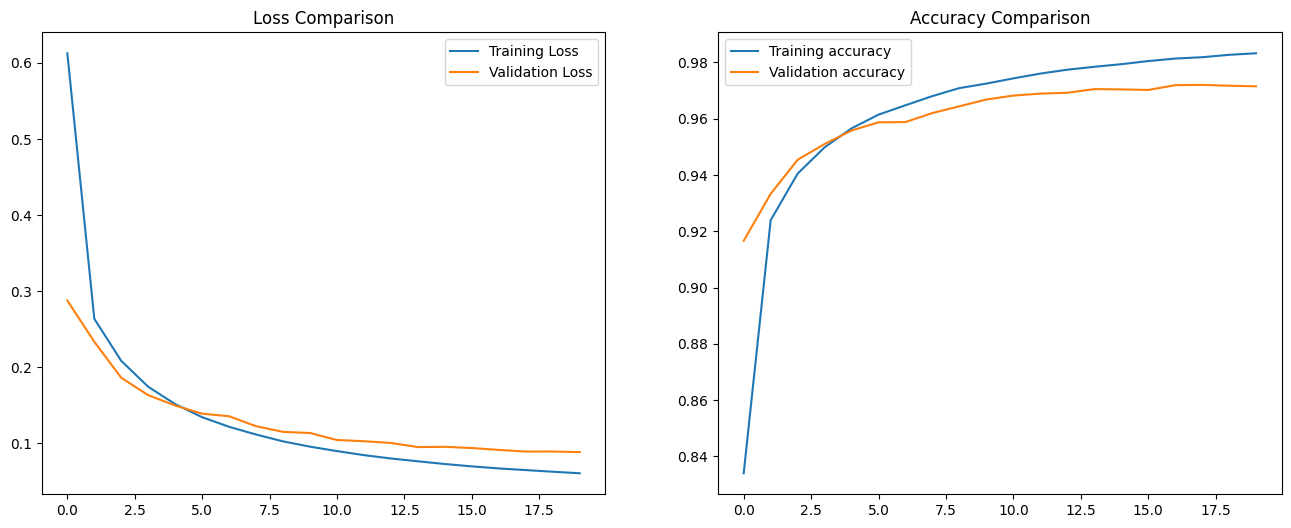

Model Performance
loss=0.0888, acc=0.9720
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Image 1: Predicted = 7, True = 7
Image 2: Predicted = 2, True = 2
Image 3: Predicted = 1, True = 1
Image 4: Predicted = 0, True = 0
Image 5: Predicted = 4, True = 4


In [39]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(history_expo.history['loss'], label='Training Loss')
axs[0].plot(history_expo.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(history_expo.history['accuracy'], label='Training accuracy')
axs[1].plot(history_expo.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()


print("="*18)
print("Model Performance")
print("="*18)
loss, acc = model_expo.evaluate(X_test, y_test, verbose=0)
print(f"loss={loss:.4f}, acc={acc:.4f}")

predictions = model_expo.predict(X_test)
for i in range(5):
    predicted_class = np.argmax(predictions[i]) 
    print(f"Image {i+1}: Predicted = {predicted_class}, True = {y_test[i]}")

In [49]:
def generate_md_table(histories, names):
    rows = []
    for hist, name in zip(histories, names):
        train_acc = hist.history['accuracy'][-1]
        val_acc = hist.history['val_accuracy'][-1]
        train_loss = hist.history['loss'][-1]
        val_loss = hist.history['val_loss'][-1]
        rows.append((name, train_acc, val_acc, train_loss, val_loss))
    
    # Print Markdown table with fixed formatting
    print("Comparison of Learning Rate Schedulers\n")
    print("| {:<20} | {:>18} | {:>18} | {:>16} | {:>14} |".format(
        "Scheduler", "Train Accuracy", "Val Accuracy", "Train Loss", "Val Loss"))
    print("|" + "-"*22 + "|" + "-"*20 + "|" + "-"*20 + "|" + "-"*18 + "|" + "-"*16 + "|")
    
    for r in rows:
        print("| {:<20} | {:>17.2f}% | {:>17.2f}% | {:>16.4f} | {:>14.4f} |".format(
            r[0], r[1]*100, r[2]*100, r[3], r[4]))


generate_md_table(
    [history_lin, history_poly, history_expo],
    ["Linear (0.01)", "Polynomial Decay", "Exponential Decay"]
)


Comparison of Learning Rate Schedulers

| Scheduler            |     Train Accuracy |       Val Accuracy |       Train Loss |       Val Loss |
|----------------------|--------------------|--------------------|------------------|----------------|
| Linear (0.01)        |             99.36% |             97.69% |           0.0262 |         0.0737 |
| Polynomial Decay     |             93.87% |             94.04% |           0.2143 |         0.2085 |
| Exponential Decay    |             98.32% |             97.15% |           0.0602 |         0.0881 |


## **Question 3**

In [44]:
optimizers = {
    "SGD (momentum=0.9)": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001),
}

In [ ]:
histories = []

for name, opt in optimizers.items():
    print(f"\n🔹 Training with {name}...\n")
    model = build_model()
    model.compile(optimizer=opt,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=batch_size,
        verbose=2
    )
    histories.append((name, history))

In [48]:
def comp_opt_table(histories):
    print("Optimizer Comparison on MNIST\n")
    print("| {:<20} | {:>18} | {:>18} | {:>16} | {:>14} |".format(
        "Optimizer", "Train Accuracy", "Val Accuracy", "Train Loss", "Val Loss"))
    print("|" + "-"*22 + "|" + "-"*20 + "|" + "-"*20 + "|" + "-"*18 + "|" + "-"*16 + "|")

    for name, hist in histories:
        train_acc = hist.history['accuracy'][-1]
        val_acc = hist.history['val_accuracy'][-1]
        train_loss = hist.history['loss'][-1]
        val_loss = hist.history['val_loss'][-1]
        print("| {:<20} | {:>17.2f}% | {:>17.2f}% | {:>16.4f} | {:>14.4f} |".format(
            name, train_acc*100, val_acc*100, train_loss, val_loss))


comp_opt_table(histories)

Optimizer Comparison on MNIST

| Optimizer            |     Train Accuracy |       Val Accuracy |       Train Loss |       Val Loss |
|----------------------|--------------------|--------------------|------------------|----------------|
| SGD (momentum=0.9)   |            100.00% |             98.23% |           0.0005 |         0.0775 |
| RMSprop              |             99.82% |             98.07% |           0.0056 |         0.1495 |
| Adam                 |             99.73% |             98.21% |           0.0084 |         0.0935 |
